In [42]:
import numpy
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [43]:
url="https://raw.githubusercontent.com/RamishaRaniK/dataset/main/insurance_pre.csv"
data_set=pd.read_csv(url)
data_set.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [44]:
rows, cols = data_set.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 1338, Columns: 6


In [45]:
#Preprocessing data
data_set

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [46]:
# One-Hot Encode Categorical (Sex,Smoker) columns
data_set = pd.get_dummies(data_set,drop_first=True)

In [47]:
data_set

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,False,True
1,18,33.770,1,1725.55230,True,False
2,28,33.000,3,4449.46200,True,False
3,33,22.705,0,21984.47061,True,False
4,32,28.880,0,3866.85520,True,False
...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False
1334,18,31.920,0,2205.98080,False,False
1335,18,36.850,0,1629.83350,False,False
1336,21,25.800,0,2007.94500,False,False


In [48]:
independent,dependent=data_set.drop('charges',axis=1),data_set['charges']
independent,dependent

(      age     bmi  children  sex_male  smoker_yes
 0      19  27.900         0     False        True
 1      18  33.770         1      True       False
 2      28  33.000         3      True       False
 3      33  22.705         0      True       False
 4      32  28.880         0      True       False
 ...   ...     ...       ...       ...         ...
 1333   50  30.970         3      True       False
 1334   18  31.920         0     False       False
 1335   18  36.850         0     False       False
 1336   21  25.800         0     False       False
 1337   61  29.070         0     False        True
 
 [1338 rows x 5 columns],
 0       16884.92400
 1        1725.55230
 2        4449.46200
 3       21984.47061
 4        3866.85520
            ...     
 1333    10600.54830
 1334     2205.98080
 1335     1629.83350
 1336     2007.94500
 1337    29141.36030
 Name: charges, Length: 1338, dtype: float64)

In [49]:
# Split training and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(independent,dependent,test_size=0.3,random_state=0)

In [50]:
X_train.shape

(936, 5)

In [51]:
X_test.shape

(402, 5)

In [52]:
y_train.shape

(936,)

In [53]:
y_test.shape

(402,)

In [28]:
#create model for Multi-linear
from sklearn.linear_model import LinearRegression
regressor= LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [30]:
# Viewing the b1 and bo value
weight=regressor.coef_
print("Weight of the model={}".format(weight))
bais=regressor.intercept_
print("Intercept of the model={}".format(bais))

Weight of the model=[  257.8006705    321.06004271   469.58113407   -41.74825718
 23418.6671912 ]
Intercept of the model=-12057.244845998526


In [32]:
y_pred = regressor.predict(X_test)

In [35]:
# evaluate the model and determine accuracy
from sklearn.metrics import r2_score
r2_score=r2_score(y_test,y_pred)
print("Multi Linear Regressor R2 Score : ",r2_score)

Multi Linear Regressor R2 Score :  0.7894790349867009


In [166]:
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [169]:
#create model for Support Vector Regression.
from sklearn.svm import SVR
regressor=SVR(kernel='sigmoid',C=1000,degree=3,epsilon=0.1,coef0=1)
regressor.fit(X_train_scaled,y_train)


SVR(C=1000, coef0=1, kernel='sigmoid')

In [171]:
# evaluate the model and determine accuracy
from sklearn.metrics import r2_score
y_pred = regressor.predict(X_test_scaled)
r2=r2_score(y_test,y_pred)
print("SVR With Standard Scaler R2 Score : ",r2)

SVR With Standard Scaler R2 Score :  -1.3731789043858589


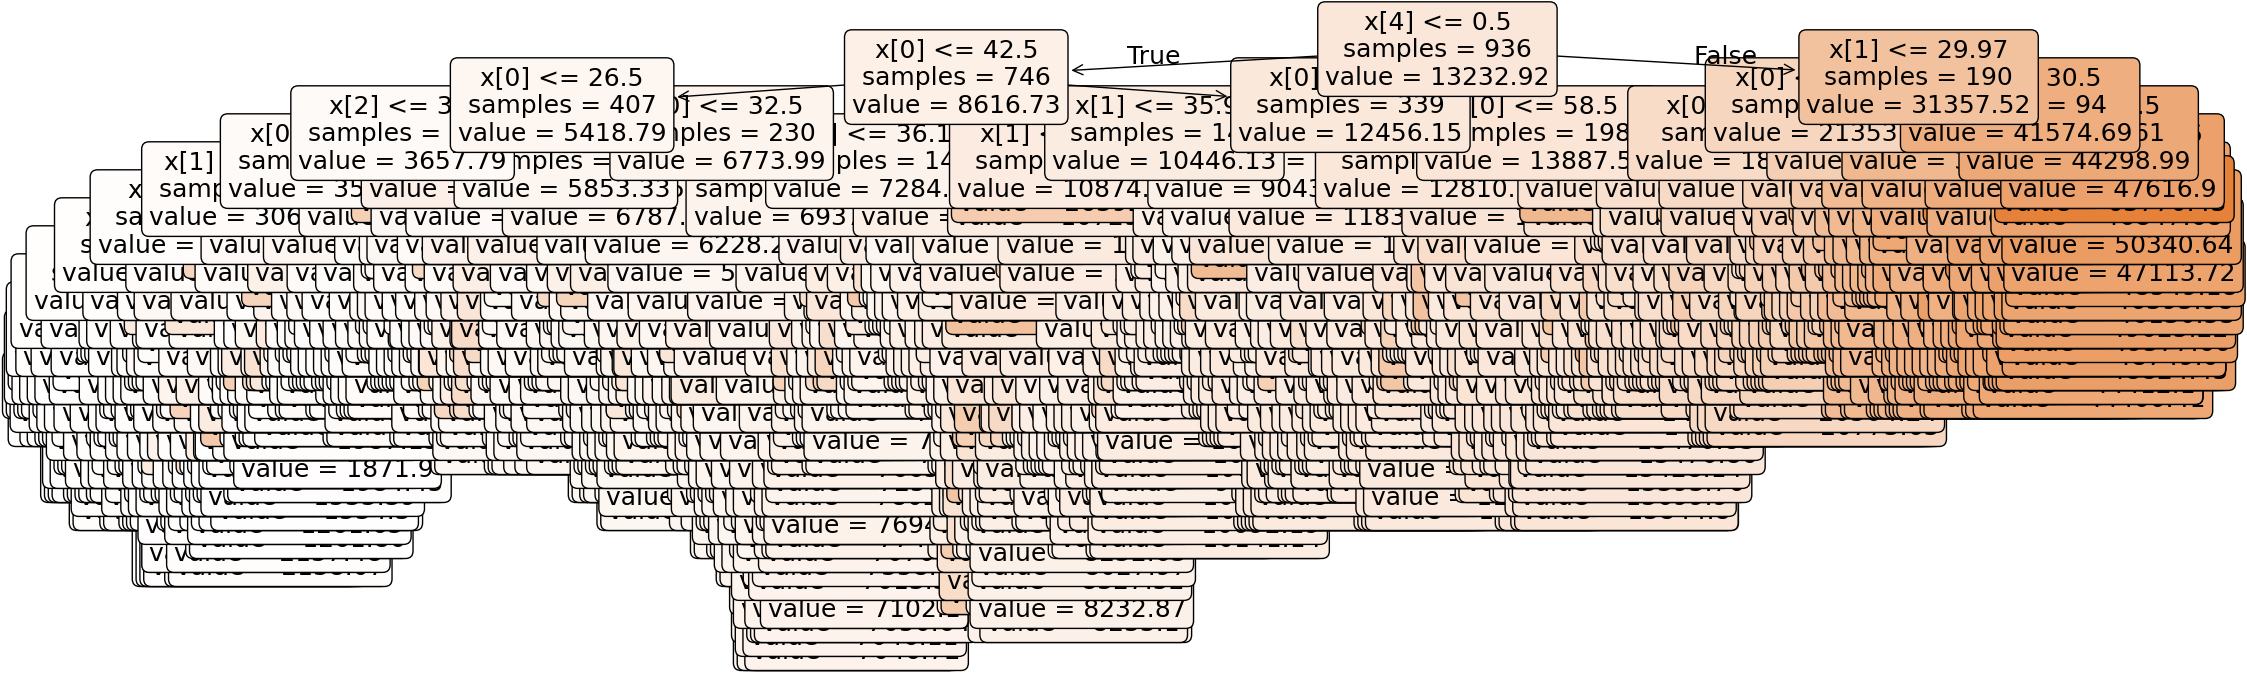

In [173]:
# create the model-decision-tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
# Train the model
regr = DecisionTreeRegressor()
regr.fit(X_train, y_train)
# Visualize the decision tree
plt.figure(figsize=(26,8))
plot_tree(regr, filled=True, rounded=True, impurity=False, fontsize=18, precision=2)
plt.show()


In [174]:
# 1. Define Parameter Grid
criterions = ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
splitters = ['best', 'random']
max_depths = [None, 5, 10, 20]
min_samples_splits = [2, 5, 10]
min_samples_leafs = [1, 2, 4]

# 2. Storage
dt_results = []

# 3. Manual Grid Search
for criterion in criterions:
    for splitter in splitters:
        for depth in max_depths:
            for min_split in min_samples_splits:
                for min_leaf in min_samples_leafs:

                    model = DecisionTreeRegressor(
                        criterion=criterion,
                        splitter=splitter,
                        max_depth=depth,
                        min_samples_split=min_split,
                        min_samples_leaf=min_leaf,
                        random_state=42
                    )

                    model.fit(X_train, y_train)
                    preds = model.predict(X_test)
                    r2 = r2_score(y_test, preds)

                    dt_results.append({
                        'criterion': criterion,
                        'splitter': splitter,
                        'max_depth': depth,
                        'min_samples_split': min_split,
                        'min_samples_leaf': min_leaf,
                        'r2_score': r2
                    })

# 4. Find Best Model
best_dt_model = max(dt_results, key=lambda x: x['r2_score'])

best_dt_model


{'criterion': 'absolute_error',
 'splitter': 'best',
 'max_depth': 5,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'r2_score': 0.8860958934822316}

In [175]:
df_results = pd.DataFrame(dt_results)
# Sort by R² descending
df_results_sorted = df_results.sort_values(by='r2_score', ascending=False)
df_results_sorted.head(10)   # show top 10 models

,criterion,splitter,max_depth,min_samples_split,min_samples_leaf,r2_score
157,absolute_error,best,5.0,5,2,0.886096
158,absolute_error,best,5.0,5,4,0.886096
161,absolute_error,best,5.0,10,4,0.886096
154,absolute_error,best,5.0,2,2,0.886096
155,absolute_error,best,5.0,2,4,0.886096
160,absolute_error,best,5.0,10,2,0.886096
170,absolute_error,best,10.0,10,4,0.884566
179,absolute_error,best,20.0,10,4,0.884476
152,absolute_error,best,NaN,10,4,0.884476
151,absolute_error,best,NaN,10,2,0.884154


In [177]:
#Create Model for Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=0)
regressor.fit(X_train,y_train)

RandomForestRegressor(random_state=0)

In [178]:
# 1. Define Parameter Grid
n_estimators_list = [50, 100, 200]
max_depth_list = [None, 5, 10, 20]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]
max_features_list = [None,'sqrt', 'log2']
bootstrap_list = [True, False]

# 2. Storage
rf_results = []

# 3. Manual Grid Search
for n_est in n_estimators_list:
    for depth in max_depth_list:
        for min_split in min_samples_split_list:
            for min_leaf in min_samples_leaf_list:
                for max_feat in max_features_list:
                    for boot in bootstrap_list:

                        model = RandomForestRegressor(
                            n_estimators=n_est,
                            max_depth=depth,
                            min_samples_split=min_split,
                            min_samples_leaf=min_leaf,
                            max_features=max_feat,
                            bootstrap=boot,
                            random_state=42,
                            n_jobs=-1
                        )

                        model.fit(X_train, y_train)
                        preds = model.predict(X_test)
                        r2 = r2_score(y_test, preds)

                        rf_results.append({
                            'n_estimators': n_est,
                            'max_depth': depth,
                            'min_samples_split': min_split,
                            'min_samples_leaf': min_leaf,
                            'max_features': max_feat,
                            'bootstrap': boot,
                            'r2_score': r2
                        })

# 4. Find Best Model
best_rf_model = max(rf_results, key=lambda x: x['r2_score'])

best_rf_model



{'n_estimators': 200,
 'max_depth': 5,
 'min_samples_split': 2,
 'min_samples_leaf': 4,
 'max_features': None,
 'bootstrap': True,
 'r2_score': 0.8915140637020081}

In [179]:
df_results = pd.DataFrame(rf_results)
# Sort by R² descending
df_results_sorted = df_results.sort_values(by='r2_score', ascending=False)
df_results_sorted.head(10)   # show top 10 models

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,r2_score
516,200,5.0,5,4,None,True,0.891514
498,200,5.0,2,4,None,True,0.891514
534,200,5.0,10,4,None,True,0.891509
282,100,5.0,2,4,None,True,0.891282
300,100,5.0,5,4,None,True,0.891282
66,50,5.0,2,4,None,True,0.891248
84,50,5.0,5,4,None,True,0.891248
318,100,5.0,10,4,None,True,0.891241
102,50,5.0,10,4,None,True,0.891201
528,200,5.0,10,2,None,True,0.890522


In [182]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# 1. Define Parameter Grid
n_estimators_list = [100, 200, 300]
learning_rate_list = [0.01, 0.05, 0.1]
max_depth_list = [2, 3, 5]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]
subsample_list = [1.0, 0.9, 0.7]
loss_list = ["squared_error", "absolute_error", "huber"]

# 2. Storage
gbr_results = []

# 3. Manual Grid Search
for n_est in n_estimators_list:
    for lr in learning_rate_list:
        for depth in max_depth_list:
            for min_split in min_samples_split_list:
                for min_leaf in min_samples_leaf_list:
                    for subs in subsample_list:
                        for loss_fn in loss_list:

                            model = GradientBoostingRegressor(
                                n_estimators=n_est,
                                learning_rate=lr,
                                max_depth=depth,
                                min_samples_split=min_split,
                                min_samples_leaf=min_leaf,
                                subsample=subs,
                                loss=loss_fn,
                                random_state=42
                            )

                            model.fit(X_train, y_train)
                            preds = model.predict(X_test)
                            r2 = r2_score(y_test, preds)

                            gbr_results.append({
                                "n_estimators": n_est,
                                "learning_rate": lr,
                                "max_depth": depth,
                                "min_samples_split": min_split,
                                "min_samples_leaf": min_leaf,
                                "subsample": subs,
                                "loss": loss_fn,
                                "r2_score": r2
                            })

# 4. Find Best Model
best_gbr_model = max(gbr_results, key=lambda x: x["r2_score"])
best_gbr_model


{'n_estimators': 100,
 'learning_rate': 0.05,
 'max_depth': 3,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'subsample': 0.7,
 'loss': 'huber',
 'r2_score': 0.8938895592690991}

In [183]:
df_results = pd.DataFrame(gbr_results)
# Sort by R² descending
df_results_sorted = df_results.sort_values(by='r2_score', ascending=False)
df_results_sorted.head(10)   # show top 10 models

,n_estimators,learning_rate,max_depth,min_samples_split,min_samples_leaf,subsample,loss,r2_score
386,100,0.05,3,10,1,0.7,huber,0.893890
332,100,0.05,3,2,1,0.7,huber,0.893865
359,100,0.05,3,5,1,0.7,huber,0.893863
1700,300,0.01,5,10,4,0.7,huber,0.893787
485,100,0.05,5,10,4,0.7,huber,0.893737
1646,300,0.01,5,2,4,0.7,huber,0.893651
1673,300,0.01,5,5,4,0.7,huber,0.893651
377,100,0.05,3,5,4,0.7,huber,0.893635
350,100,0.05,3,2,4,0.7,huber,0.893635
404,100,0.05,3,10,4,0.7,huber,0.893617
